In [1]:
import os, sys
os.environ["PYTHONUTF8"] = "1"
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")
if hasattr(sys.stderr, "reconfigure"):
    sys.stderr.reconfigure(encoding="utf-8")

%cd /content
!git clone https://github.com/Darkin72/VDT_GD2.git
!if [ ! -d VDT_GD2/solution/GridDehazeNet/.git ]; then git clone https://github.com/Darkin72/GridDehazeNet.git VDT_GD2/solution/GridDehazeNet; fi
!if [ ! -d VDT_GD2/solution/DehazeDDPM/.git ]; then git clone https://github.com/Darkin72/DehazeDDPM.git VDT_GD2/solution/DehazeDDPM; fi
!if [ ! -d VDT_GD2/solution/UDPNet/.git ]; then git clone https://github.com/Darkin72/UDPNet.git VDT_GD2/solution/UDPNet; fi
!if [ ! -d VDT_GD2/solution/MB-TaylorFormerV2/.git ]; then git clone https://github.com/Darkin72/MB-TaylorFormerV2.git VDT_GD2/solution/MB-TaylorFormerV2; fi
%cd /content/VDT_GD2


/content
Cloning into 'VDT_GD2'...
remote: Enumerating objects: 1816, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 1816 (delta 13), reused 22 (delta 7), pack-reused 1786 (from 3)
Receiving objects: 100% (1816/1816), 1.05 GiB | 32.39 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Updating files: 100% (1721/1721), done.
Cloning into 'VDT_GD2/solution/GridDehazeNet'...
remote: Enumerating objects: 2693, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 2693 (delta 7), reused 4 (delta 3), pack-reused 2680 (from 4)
Receiving objects: 100% (2693/2693), 821.27 MiB | 35.53 MiB/s, done.
Resolving deltas: 100% (47/47), done.
Updating files: 100% (2600/2600), done.
Cloning into 'VDT_GD2/solution/DehazeDDPM'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 70 (

In [2]:
%cd /content/VDT_GD2
!git pull
%cd solution/GridDehazeNet
!git pull
%cd ../DehazeDDPM
!git pull
%cd ../UDPNet
!git pull
%cd ../MB-TaylorFormerV2
!git pull

/content/VDT_GD2
Already up to date.
/content/VDT_GD2/solution/GridDehazeNet
Already up to date.
/content/VDT_GD2/solution/DehazeDDPM
Already up to date.


In [3]:
!pip install -q opencv-python tqdm numpy pillow scipy scikit-image

In [4]:
import torch

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

2.11.0+cu130
CUDA available: True
NVIDIA A100-SXM4-80GB


In [10]:
%cd /content/VDT_GD2

!python utils/evaluate_griddehazenet.py \
    --device cuda \
    --output-dir utils/evaluation_results/griddehazenet

/content/VDT_GD2
Đánh giá griddehazenet: 100% 75/75 [00:35<00:00,  2.13ảnh/s, dataset=i-haze, psnr=11.96, ssim=0.676]

KẾT QUẢ TỔNG HỢP
Dataset              N       PSNR       SSIM      ΔPSNR      ΔSSIM       ms/ảnh
i-haze               5    14.3965     0.7232     1.7342     0.0298      1366.48
sots-indoor         70    33.2144     0.9860    21.1679     0.3190        54.64
all                 75    31.9599     0.9685    19.8724     0.2997       142.10

Hardware: x86_64 | CPU cores: 12
GPU: NVIDIA A100-SXM4-80GB | VRAM peak allocated: 19.29 GB / 79.25 GB
RAM peak: 1.79 GB | FPS toàn bộ run: 2.1302 | FPS suy luận trung bình: 7.0373

KẾT QUẢ THEO NGUỒN DỮ LIỆU
Nguồn                N       PSNR       SSIM      ΔPSNR      ΔSSIM       ms/ảnh
real                 5    14.3965     0.7232     1.7342     0.0298      1366.48
synthetic           70    33.2144     0.9860    21.1679     0.3190        54.64

KẾT QUẢ THEO MỨC SƯƠNG SOTS
Dataset          Mức          N       PSNR       SSIM      ΔPSNR 

In [11]:
!python utils/evaluate.py \
    --solution dcp \
    --dataset all \
    --split test \
    --output-dir utils/evaluation_results/dcp

!python utils/evaluate.py \
    --solution cap \
    --dataset all \
    --split test \
    --output-dir utils/evaluation_results/cap

Đánh giá dcp: 100% 152/152 [01:24<00:00,  1.79ảnh/s, dataset=sots-outdoor, psnr=15.52, ssim=0.845]

KẾT QUẢ TỔNG HỢP
Dataset              N       PSNR       SSIM      ΔPSNR      ΔSSIM       ms/ảnh
i-haze               5    11.5416     0.5886    -1.1207    -0.1048      2875.14
o-hazy               7    14.2958     0.5722    -0.0915    -0.0457      2367.60
sots-indoor         70    21.7042     0.8915     9.6578     0.2245        49.42
sots-outdoor        70    17.0989     0.8623    -0.0832     0.0229        45.68
all                152    18.9079     0.8534     4.3682     0.1084       247.41

Hardware: x86_64 | CPU cores: 12
RAM peak: 1.23 GB | FPS toàn bộ run: 1.7898 | FPS suy luận trung bình: 4.0419

KẾT QUẢ THEO NGUỒN DỮ LIỆU
Nguồn                N       PSNR       SSIM      ΔPSNR      ΔSSIM       ms/ảnh
real                12    13.1483     0.5790    -0.5203    -0.0703      2579.08
synthetic          140    19.4016     0.8769     4.7873     0.1237        47.55

KẾT QUẢ THEO MỨC SƯƠNG

In [5]:
%cd /content/VDT_GD2
!pip install -q gdown tensorboardX lmdb pyyaml einops pytorch_msssim natsort openpyxl psutil
!mkdir -p /content/ddpm_checkpoints
!gdown --folder "https://drive.google.com/drive/folders/1I7sH6vb9oWOZeIVu6-xh9Xm5lnwdzHa7?usp=drive_link" -O /content/ddpm_checkpoints


/content/VDT_GD2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.8/346.8 kB 21.2 MB/s eta 0:00:00
Retrieving folder contents
Processing file 1l7IjeYT48vTbwJzENQqzuxRH8sskOTcL DENSE_I130000_E2600_gen.pth
Processing file 1XDFKJprqNuhSlmJE2GZHpIMyk0u9LHsq DENSE_I690000_E53077_gen.pth
Processing file 1-IJZHFMtIk3h0KMLyH84FXeeJUspS83r NH_I230000_E4600_gen.pth
Processing file 1E79_e-6rxloxaqg8NBaygTSX8BoJNb-K NH_I410000_E31539_gen.pth
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1l7IjeYT48vTbwJzENQqzuxRH8sskOTcL
From (redirected): https://drive.google.com/uc?id=1l7IjeYT48vTbwJzENQqzuxRH8sskOTcL&confirm=t&uuid=818499e0-8903-4811-b4f4-6124d6c3414e
To: /content/ddpm_checkpoints/DENSE_I130000_E2600_gen.pth
100% 370M/370M [00:08<00:00, 45.3MB/s]
Downloading...
From (original): https://drive.google.c

In [6]:
from pathlib import Path
import shutil

source_dir = Path("/content/ddpm_checkpoints")
target_dir = Path("/content/VDT_GD2/solution/DehazeDDPM/Diffusion_trained_pth")
target_dir.mkdir(parents=True, exist_ok=True)
expected = ["DENSE_I130000_E2600_gen.pth", "NH_I230000_E4600_gen.pth"]
for name in expected:
    matches = list(source_dir.rglob(name))
    if not matches:
        raise FileNotFoundError(f"Missing checkpoint: {name} in {source_dir}")
    shutil.copy2(matches[0], target_dir / name)
    print(f"Copied: {target_dir / name}")


Copied: /content/VDT_GD2/solution/DehazeDDPM/Diffusion_trained_pth/DENSE_I130000_E2600_gen.pth
Copied: /content/VDT_GD2/solution/DehazeDDPM/Diffusion_trained_pth/NH_I230000_E4600_gen.pth


In [7]:
import torch
from pathlib import Path

for path in [
    Path("/content/VDT_GD2/solution/DehazeDDPM/Diffusion_trained_pth/DENSE_I130000_E2600_gen.pth"),
    Path("/content/VDT_GD2/solution/DehazeDDPM/Diffusion_trained_pth/NH_I230000_E4600_gen.pth"),
]:
    checkpoint = torch.load(path, map_location="cpu", weights_only=False)
    print(path.name, path.stat().st_size / 1024**3, "GB", type(checkpoint).__name__)
    print("keys:", list(checkpoint)[:10] if isinstance(checkpoint, dict) else "non-dict")


DENSE_I130000_E2600_gen.pth 0.34502775128930807 GB OrderedDict
keys: ['betas', 'alphas_cumprod', 'alphas_cumprod_prev', 'sqrt_alphas_cumprod', 'sqrt_one_minus_alphas_cumprod', 'log_one_minus_alphas_cumprod', 'sqrt_recip_alphas_cumprod', 'sqrt_recipm1_alphas_cumprod', 'posterior_variance', 'posterior_log_variance_clipped']
NH_I230000_E4600_gen.pth 0.34502775128930807 GB OrderedDict
keys: ['betas', 'alphas_cumprod', 'alphas_cumprod_prev', 'sqrt_alphas_cumprod', 'sqrt_one_minus_alphas_cumprod', 'log_one_minus_alphas_cumprod', 'sqrt_recip_alphas_cumprod', 'sqrt_recipm1_alphas_cumprod', 'posterior_variance', 'posterior_log_variance_clipped']


In [8]:
from pathlib import Path
import json

ROOT = Path("/content/VDT_GD2")
DDPM = ROOT / "solution/DehazeDDPM"
DENSE_GEN = DDPM / "Diffusion_trained_pth/DENSE_I130000_E2600_gen.pth"
NH_GEN = DDPM / "Diffusion_trained_pth/NH_I230000_E4600_gen.pth"

def load_json_without_comments(path):
    text = "".join(line.split("//")[0] + "\n" for line in path.read_text().splitlines())
    return json.loads(text)

def configure_ddpm_config(config_name, lq_dir, gt_dir, diffusion_gen, prenet, image_size=512, limit=1):
    path = DDPM / "config" / config_name
    config = load_json_without_comments(path)
    config["phase"] = "val"
    config["gpu_ids"] = [0]
    config["path"]["resume_state"] = str(diffusion_gen).removesuffix("_gen.pth")
    config["path"]["resume_stateH"] = str(prenet)
    val = config["datasets"]["val"]
    val["datarootlq"] = str(lq_dir)
    val["dataroothq"] = str(gt_dir)
    val["img_sizeH"] = image_size
    val["img_sizeW"] = image_size
    val["len"] = limit
    path.write_text(json.dumps(config, indent=2), encoding="utf-8")
print(f"Updated DDPM config: {path}")

# Smoke test on one I-HAZE pair; rename hazy input so DDPM matches by basename.
configure_ddpm_config(
    "test_NH.json",
    ROOT / "dataset/Synthetic Objective Testing Set (SOTS) [RESIDE]/indoor/test/hazy",
    ROOT / "dataset/Synthetic Objective Testing Set (SOTS) [RESIDE]/indoor/test/clear",
    NH_GEN,
    DDPM / "pretrained_PreNet_pth/NH_net_g_80000.pth",
)


Updated DDPM config: /content/VDT_GD2/solution/DehazeDDPM/Diffusion_trained_pth/NH_I230000_E4600_gen.pth


In [16]:
# CUDA/NVRTC diagnostic. Restart the Colab runtime after changing CUDA packages.
import glob, torch
print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("NVRTC libraries:", glob.glob("/usr/local/lib/python*/dist-packages/nvidia/*/lib/libnvrtc-builtins.so*"))


PyTorch: 2.11.0+cu130
CUDA build: 13.0
CUDA available: True
NVRTC libraries: ['/usr/local/lib/python3.13/dist-packages/nvidia/cu13/lib/libnvrtc-builtins.so.13.0', '/usr/local/lib/python3.13/dist-packages/nvidia/cuda_nvrtc/lib/libnvrtc-builtins.so.12.9']


In [17]:
%cd /content/VDT_GD2/solution/DehazeDDPM
!python infer.py -c config/test_NH.json -p val -gpu 0


/content/VDT_GD2/solution/DehazeDDPM
export CUDA_VISIBLE_DEVICES=0
26-09-23 19:07:09.556 - INFO:   name: Dehaze_test
  phase: val
  gpu_ids: [0]
  path:[
    log: experiments/Dehaze_test_260923_190709/logs
    tb_logger: experiments/Dehaze_test_260923_190709/tb_logger
    results: experiments/Dehaze_test_260923_190709/results
    checkpoint: experiments/Dehaze_test_260923_190709/checkpoint
    resume_state: /content/VDT_GD2/solution/DehazeDDPM/Diffusion_trained_pth/DENSE_I130000_E2600
    resume_stateH: /content/VDT_GD2/solution/DehazeDDPM/pretrained_PreNet_pth/DENSE_net_g_120000.pth
    experiments_root: experiments/Dehaze_test_260923_190709
  ]
  datasets:[
    train:[
      name: ITS
      img_sizeH: 560
      img_sizeW: 752
      datarootlq: ./data/Dense_Haze/hazy_train
      dataroothq: ./data/Dense_Haze/GT_train
      datatype: img
      batch_size: 1
      num_workers: 0
      use_shuffle: True
      len: -1
    ]
    val:[
      name: SOTS
      img_sizeH: 512
      img_sizeW: 

Latest run: /content/VDT_GD2/solution/DehazeDDPM/experiments/Dehaze_test_260923_190709
Result directory: /content/VDT_GD2/solution/DehazeDDPM/experiments/Dehaze_test_260923_190709/results
Log directory: /content/VDT_GD2/solution/DehazeDDPM/experiments/Dehaze_test_260923_190709/logs
Output images: 2

--- train.log (last 3000 chars) ---
26-09-23 19:07:09.556 - INFO:   name: Dehaze_test
  phase: val
  gpu_ids: [0]
  path:[
    log: experiments/Dehaze_test_260923_190709/logs
    tb_logger: experiments/Dehaze_test_260923_190709/tb_logger
    results: experiments/Dehaze_test_260923_190709/results
    checkpoint: experiments/Dehaze_test_260923_190709/checkpoint
    resume_state: /content/VDT_GD2/solution/DehazeDDPM/Diffusion_trained_pth/DENSE_I130000_E2600
    resume_stateH: /content/VDT_GD2/solution/DehazeDDPM/pretrained_PreNet_pth/DENSE_net_g_120000.pth
    experiments_root: experiments/Dehaze_test_260923_190709
  ]
  datasets:[
    train:[
      name: ITS
      img_sizeH: 560
      img_siz

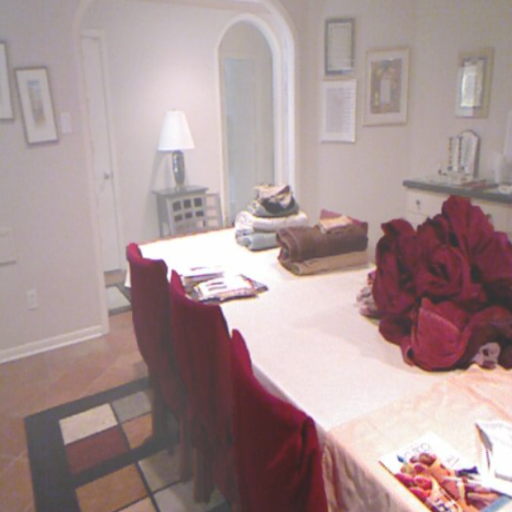

0_1_out.png


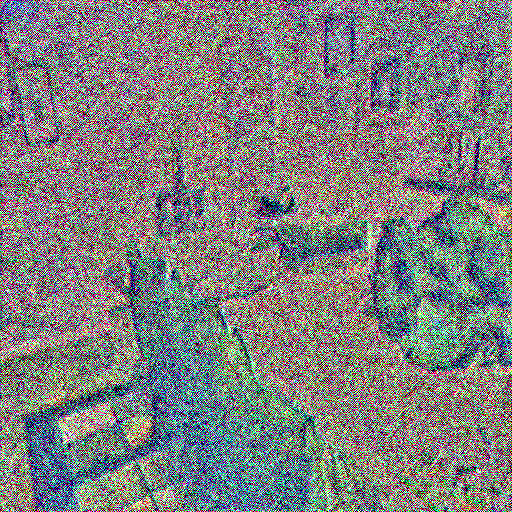

In [18]:
# Inspect the latest DehazeDDPM-NH run.
from pathlib import Path
from IPython.display import Image, display

experiments_root = Path("/content/VDT_GD2/solution/DehazeDDPM/experiments")
runs = sorted(experiments_root.glob("Dehaze_test_*"), key=lambda path: path.stat().st_mtime)
if not runs:
    print("No DehazeDDPM run directory found.")
else:
    latest_run = runs[-1]
    result_dir = latest_run / "results"
    log_dir = latest_run / "logs"
    images = sorted(result_dir.glob("*.png"))
    print("Latest run:", latest_run)
    print("Result directory:", result_dir)
    print("Log directory:", log_dir)
    print("Output images:", len(images))
    if not images:
        print("No output image was written. Check the inference cell error above; the model must finish before results are saved.")
    for log_path in sorted(log_dir.glob("*.log")):
        print(f"\n--- {log_path.name} (last 3000 chars) ---")
        print(log_path.read_text(encoding="utf-8", errors="replace")[-3000:])
    for image_path in images[:10]:
        print(image_path.name)
        display(Image(filename=str(image_path), width=512))


## DehazeDDPM-NH: generate four Excel reports
This evaluates all four datasets with the NH checkpoint and writes dataset, domain, fog-level and hardware workbooks.


In [ ]:
%cd /content/VDT_GD2
!python utils/evaluate_ddpm.py \
    --device cuda \
    --config solution/DehazeDDPM/config/test_NH.json \
    --checkpoint solution/DehazeDDPM/Diffusion_trained_pth/NH_I230000_E4600_gen.pth \
    --prenet solution/DehazeDDPM/pretrained_PreNet_pth/NH_net_g_80000.pth \
    --output-dir utils/evaluation_results/dehazeddpm_nh \
    --save-images


## UDPNet and MB-TaylorFormerV2
Download checkpoints from Google Drive and evaluate on the common test split.


In [ ]:
%cd /content/VDT_GD2
!mkdir -p /content/udp_checkpoints /content/mb_taylorformerv2_checkpoints
!gdown --folder "https://drive.google.com/drive/folders/1_XDXqcdqF5DuuZSGQQC4Je_5SZer7-Jv?usp=drive_link" -O /content/udp_checkpoints
!gdown --folder "https://drive.google.com/drive/folders/1_85eRPM2ZMU74BEziHFXktp2um1ueUoC?usp=drive_link" -O /content/mb_taylorformerv2_checkpoints


In [ ]:
from pathlib import Path
import shutil
root = Path("/content/VDT_GD2")
udp_src = Path("/content/udp_checkpoints"); mb_src = Path("/content/mb_taylorformerv2_checkpoints")
udp_dst = root / "UDPNet_checkpoints"; mb_dst = root / "mb-taylorformerv2"
udp_dst.mkdir(exist_ok=True); mb_dst.mkdir(exist_ok=True)
for name in ["FSNet_UDPNet_ITS.ckpt", "FSNet_UDPNet_OTS.ckpt", "ConvIR_UDPNet_ITS.ckpt", "ConvIR_UDPNet_OTS.ckpt"]:
    matches = list(udp_src.rglob(name))
    if matches: shutil.copy2(matches[0], udp_dst / name); print("Copied", name)
for name in ["ITS-B.pth", "ITS-L.pth", "OTS-B.pth", "OTS-L.pth"]:
    matches = list(mb_src.rglob(name))
    if matches: shutil.copy2(matches[0], mb_dst / name); print("Copied", name)


In [ ]:
%cd /content/VDT_GD2
!pip install -q transformers thop
!python utils/evaluate_mb_taylorformerv2.py --size B --checkpoint-dir mb-taylorformerv2 --device cuda --max-side 512 --batch-size 2 --output-dir utils/evaluation_results/mb_taylorformerv2 --save-images
!python utils/evaluate_udpnet.py --model FSNet --checkpoint-dir UDPNet_checkpoints --depth-model depth-anything/Depth-Anything-V2-Base-hf --device cuda --max-side 512 --batch-size 2 --output-dir utils/evaluation_results/udpnet --save-images
